# Last Pieces Moved In Chess

Author: Jonathon Lopez

Course Project, UC Irvine, Math 10, Winter 2025

## Introduction

My project will be analyzing a chess dataset that was made using the website, LiChess. I will be making models demonstrating how certain factors affect different outcomes in the game. For the majority of the project, I will focus on how different factors affect final piece moves.

Here is the link to where the dataset was obtained: https://openml.org/search?type=data&status=active&id=45951&sort=runs

Below are the descriptions of each column as given by the creator of the dataset:
* "id: A unique identifier for each game represented by strings like 'JRpms95z'.
* rated: A boolean indicating if the game was rated (True) or not.
* created_at: The timestamp when the game was created, in milliseconds.
* last_move_at: The timestamp for the last move made in the game.
* turns: The total number of turns taken in the game.
* victory_status: The method by which the game was won ('mate', 'resign', etc.).
* winner: The side that won the game ('white', 'black', or 'draw').
* increment_code: Time control settings for the game, represented in a string like '7+9'.
* white_id: The username of the player controlling the white pieces.
* white_rating: The rating of the white player at the time of the game.
* black_id: The username of the player controlling the black pieces.
* black_rating: The rating of the black player at the time of the game.
* moves: The sequence of moves made during the game, recorded in standard chess notation.
* opening_eco: The Encyclopaedia of Chess Openings (ECO) code for the game's opening.
* opening_name: The name of the opening played, like "King's Indian Defense".
* opening_ply: The number of moves in the opening phase."

## Importing Libraries and Loading the Data Frame

In [1]:
import pandas as pd
import altair as alt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn import tree
from itertools import product

The following code is used to enable visibility in GitHub.

In [2]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

alt.renderers.enable('png')

RendererRegistry.enable('png')

In [3]:
df_pre = pd.read_csv("games.csv")

In [4]:
df_pre

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,2017-08-31 20:06:40,2017-08-31 20:06:40,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,2017-08-30 21:53:20,2017-08-30 21:53:20,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,2017-08-30 21:53:20,2017-08-30 21:53:20,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,2017-08-30 16:20:00,2017-08-30 16:20:00,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,2017-08-29 18:06:40,2017-08-29 18:06:40,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20053,EfqH7VVH,True,2017-07-11 16:35:14.342000,2017-07-11 16:40:36.076000,24,resign,white,10+10,belcolt,1691,jamboger,1220,d4 f5 e3 e6 Nf3 Nf6 Nc3 b6 Be2 Bb7 O-O Be7 Ne5...,A80,Dutch Defense,2
20054,WSJDhbPl,True,2017-07-10 14:48:09.760000,2017-07-10 15:00:33.979000,82,mate,black,10+0,jamboger,1233,farrukhasomiddinov,1196,d4 d6 Bf4 e5 Bg3 Nf6 e3 exd4 exd4 d5 c3 Bd6 Bd...,A41,Queen's Pawn,2
20055,yrAas0Kj,True,2017-07-10 14:44:37.493000,2017-07-10 14:47:30.327000,35,mate,white,10+0,jamboger,1219,schaaksmurf3,1286,d4 d5 Bf4 Nc6 e3 Nf6 c3 e6 Nf3 Be7 Bd3 O-O Nbd...,D00,Queen's Pawn Game: Mason Attack,3
20056,b0v4tRyF,True,2017-07-10 14:15:27.019000,2017-07-10 14:31:13.718000,109,resign,white,10+0,marcodisogno,1360,jamboger,1227,e4 d6 d4 Nf6 e5 dxe5 dxe5 Qxd1+ Kxd1 Nd5 c4 Nb...,B07,Pirc Defense,4


## Setting Up The Data Frame

Before beginning my project, I want to make some changes and additions to the dataframe. I will start by first seeing if there are any missing values.

In [5]:
df_pre.isnull().sum()

id                0
rated             0
created_at        0
last_move_at      0
turns             0
victory_status    0
winner            0
increment_code    0
white_id          0
white_rating      0
black_id          0
black_rating      0
moves             0
opening_eco       0
opening_name      0
opening_ply       0
dtype: int64

We can see that there are no missing values, so nothing needs to be done in that regard.

I am now going to specify that it must be a rated game to eliminate any games where there is potential for non-standard play. I will also only be looking at games which end in checkmate or resignation, so I will be making that change to the dataframe as well.

In [6]:
df = df_pre[df_pre["rated"] == True]
df = df[df["victory_status"].isin(["mate", "resign"])]

There was an issue in the dataframe where "the created_at" and "last_move_at" columns could be matching (which shouldn't be possible), so I will be removing them. I will also be converting the columns into datetimes to make them easier to work with.

In [7]:
df = df[df["created_at"] != df["last_move_at"]]
df["created_at"] = pd.to_datetime(df["created_at"], format = "mixed")
df["last_move_at"] = pd.to_datetime(df["last_move_at"], format = "mixed")

There are some columns that I won't be using so I will be dropping them to make the dataframe cleaner.

In [8]:
df.drop(columns=["id","increment_code","white_id","black_id","opening_eco","opening_name","opening_ply"], inplace=True)

By looking at the first letter of the final move, I can see which piece was moved last. I will be creating a function which identifies said piece.

In [9]:
def identify_final_piece(move):
    final_move = move.split(" ")[-1]
    piece = final_move[0]
    
    if piece == "K":
        return "King"
    elif piece == "Q":
        return "Queen"
    elif piece == "B":
        return "Bishop"
    elif piece == "N":
        return "Knight"
    elif piece == "R":
        return "Rook"
    else:
        return "Pawn"

I will apply the above function to the "moves" column in the dataframe and create a new column containing the result which is the last piece that was moved in the match.

In [10]:
df["last_piece"] = df["moves"].apply(lambda x: identify_final_piece(x))

Here I will make 3 new columns, which have amount of captures made by white, by black, and in total. 

In [11]:
df["white_captures"] = df["moves"].apply(lambda x: ''.join(x.split(" ")[::2]).count('x'))
df["black_captures"] = df["moves"].apply(lambda x: ''.join(x.split(" ")[1::2]).count('x'))
df["total_captures"] = df["moves"].apply(lambda x: ''.join(x.split(" ")).count('x'))

For the above, I could have also gotten "total_captures" by adding "white_captures" and "black_captures", but I wanted to make it its own seperate code that way the columns can be used to check one another.

Using the difference of "last_move_at" and "created_at" in minutes, I will create a new column "time_minutes" which is the length of the game in minutes.

In [12]:
df["time_minutes"] = (((df["last_move_at"] - df["created_at"]).dt.total_seconds()) / 60).round()

In [13]:
df["time_minutes"].value_counts()

time_minutes
167.0    474
8.0      474
7.0      473
5.0      433
11.0     430
        ... 
106.0      1
94.0       1
103.0      1
92.0       1
80.0       1
Name: count, Length: 112, dtype: int64

Looking at the time values, there is an innacuracy with 474 matches being roughly 167 minutes long. This is clearly incorrect as there should not be that many games that are almost 3 hours long, so I will be removing these rows.

In [14]:
df = df[df["time_minutes"] != 167]

Using the rating of each player and the winner, I will create a new column determining if the game was won by the higher rated player.

In [15]:
df["winner_higher_rated"] = (
    ((df["white_rating"] > df["black_rating"]) & (df["winner"] == "white"))|
    ((df["black_rating"] > df["white_rating"]) & (df["winner"] == "black"))
)

I will create a new column "rating_average" which takes the average rating between the two players in a game.

In [16]:
df["rating_average"] = ((df["white_rating"] + df["black_rating"]) / 2).round()

In [17]:
for col in df.columns:
    if df[col].apply(lambda x: isinstance(x, (np.ndarray, list))).any():
        df[col] = df[col].apply(lambda x: x[0] if isinstance(x, (np.ndarray, list)) and len(x) > 0 else x)


Now that I am finished working on the dataframe, I will reset the index.

In [18]:
df = df.reset_index(drop = True)
df

,rated,created_at,last_move_at,turns,victory_status,winner,white_rating,black_rating,moves,last_piece,white_captures,black_captures,total_captures,time_minutes,winner_higher_rated,rating_average
0,True,2014-12-10 13:02:58.172,2014-12-10 13:06:18.617,21,mate,white,1459,1143,e4 e5 Nf3 Nf6 Nxe5 Nxe4 Qf3 Ke7 Qxf7+ Kd6 Nc4+...,Pawn,3,2,5,3.0,True,1301.0
1,True,2014-12-10 13:00:11.633,2014-12-10 13:02:52.431,20,mate,black,1175,1455,a4 a6 c4 Nc6 b3 e6 h4 Qf6 Nc3 Bb4 Bb2 Ne5 e4 h...,Queen,1,0,1,3.0,True,1315.0
2,True,2014-11-19 12:37:33.558,2014-11-19 12:48:09.197,43,mate,white,1466,1500,d4 b5 e4 d5 e5 h5 Bxb5+ c6 Ba4 Bd7 Nc3 f5 Bg5 ...,Queen,5,2,7,11.0,False,1483.0
3,True,2015-01-24 11:28:05.917,2015-01-24 11:35:37.813,29,resign,white,1773,1366,e4 e5 d4 Bd6 dxe5 Bxe5 Nf3 Bd6 Nc3 Nf6 e5 Bc5 ...,Knight,6,4,10,8.0,True,1570.0
4,True,2015-01-22 15:39:28.269,2015-01-22 15:49:33.107,34,mate,black,1385,1246,d4 Nc6 d5 Nb4 e4 c6 Qd3 Nxd3+ Bxd3 cxd5 exd5 g...,Queen,3,5,8,10.0,False,1316.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7559,True,2017-07-11 16:35:14.342,2017-07-11 16:40:36.076,24,resign,white,1691,1220,d4 f5 e3 e6 Nf3 Nf6 Nc3 b6 Be2 Bb7 O-O Be7 Ne5...,Pawn,2,2,4,5.0,True,1456.0
7560,True,2017-07-10 14:48:09.760,2017-07-10 15:00:33.979,82,mate,black,1233,1196,d4 d6 Bf4 e5 Bg3 Nf6 e3 exd4 exd4 d5 c3 Bd6 Bd...,Queen,9,12,21,12.0,False,1214.0
7561,True,2017-07-10 14:44:37.493,2017-07-10 14:47:30.327,35,mate,white,1219,1286,d4 d5 Bf4 Nc6 e3 Nf6 c3 e6 Nf3 Be7 Bd3 O-O Nbd...,Queen,2,2,4,3.0,False,1252.0
7562,True,2017-07-10 14:15:27.019,2017-07-10 14:31:13.718,109,resign,white,1360,1227,e4 d6 d4 Nf6 e5 dxe5 dxe5 Qxd1+ Kxd1 Nd5 c4 Nb...,Rook,14,11,25,16.0,True,1294.0


## Does the higher rated player usually win?

Before getting to the main focus of the project which highlights final piece moves, I wanted to first look at data regarding whether or not the higher rated player usually wins. Chess games will usually match players who are close in rating to each other, so I am curious about how much of a difference the rating really makes. Not only that, but I also want to see how this changes based on the average rating of the match.

I will use four different pie charts that consist of games whose rating is in a certain range. I want there to be an even amount of games in each range, so I will use the describe method to see where I should make the splits.

In [19]:
df["rating_average"].describe()

count    7564.000000
mean     1611.756610
std       257.675611
min       816.000000
25%      1426.000000
50%      1596.000000
75%      1790.000000
max      2405.000000
Name: rating_average, dtype: float64

Based on the above, I wish to make ranges from 816-1426, 1426-1596, 1596-1790, and 1790-2405. I will create 4 dataframes, one for each range.

In [20]:
df_q1_pre = df[(df["rating_average"] >= 816) & (df["rating_average"] < 1426)]
df_q2_pre = df[(df["rating_average"] >= 1426) & (df["rating_average"] < 1596)]
df_q3_pre = df[(df["rating_average"] >= 1596) & (df["rating_average"] < 1790)]
df_q4_pre = df[(df["rating_average"] >= 1790) & (df["rating_average"] < 2405)]

Each dataframe might have a slightly different number of rows, so I will change them to all match the amount of rows in the smallest dataframe. I will just be taking the head of each one instead of sampling since it will help to make the ranges more distinct.

In [21]:
min_row = min(len(df_q1_pre), len(df_q2_pre), len(df_q3_pre), len(df_q4_pre))

df_q1_pre = df_q1_pre.head(min_row)
df_q2_pre = df_q2_pre.head(min_row)
df_q3_pre = df_q3_pre.head(min_row)
df_q4_pre = df_q4_pre.head(min_row)

Now that the dataframes are split up, I want to change each into a new dataframe which demonstrates how many times the higher rated player won, and how many times the lower rated player won. I will make a function that can be used on each dataframe.

In [22]:
def winner_higher_rated(df):
    df_winner_higher_rated = df["winner_higher_rated"].value_counts().reset_index()
    df_winner_higher_rated.columns = ["status", "count"]
    df_winner_higher_rated["status"] = df_winner_higher_rated["status"].replace({True: "Higher Rated", False: "Lower Rated"})
    return df_winner_higher_rated

I will now apply the function to each dataframe and store them in new dataframes.

In [23]:
df_q1 = winner_higher_rated(df_q1_pre)
df_q2 = winner_higher_rated(df_q2_pre)
df_q3 = winner_higher_rated(df_q3_pre)
df_q4 = winner_higher_rated(df_q4_pre)

I will create a function to make a pie chart for each dataframe. It will take in the dataframe and desired title.

In [24]:
def make_pie_chart(df, title):

    percent =(df["count"][0] / df["count"].sum() * 100).round(1)

    return alt.Chart(df).mark_arc().encode(
        theta = "count",
        color = "status"
    ).properties(
        width = 200, 
        height = 200, 
        title = [title, f"Higher Rated Wins: {percent}%"]
    )

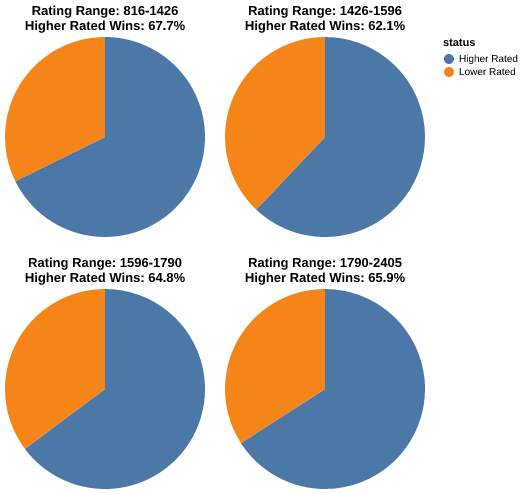

In [25]:
c1 = make_pie_chart(df_q1, "Rating Range: 816-1426")
c2 = make_pie_chart(df_q2, "Rating Range: 1426-1596")
c3 = make_pie_chart(df_q3, "Rating Range: 1596-1790")
c4 = make_pie_chart(df_q4, "Rating Range: 1790-2405")

(c1 | c2) & (c3 | c4)

Based on the pie charts and the associated percentages, we can see that the impact of being the higher rated player was the largest for range 816-1426 and the lowest for 1426-1596. Overall, it is clear that higher rated player is more liklely to win than the lower rated player in all ranges.

## Final Moves Resulting in Checkmates and Resignations

For this section, I want to analyze data in regards to which pieces were moved last that result in either checkmate or resignation. To do this, I will be making bar charts which display the number of times each piece was moved last that resulted in their respective game outcome.

I am going to create three charts:
* Chart 1: Final Piece Moved Resulting in Checkmate
* Chart 2: Final Piece Moved Resulting in Resignation
* Chart 3: Final Piece Moved Resulting in Either Checkmate or Resignation
To start this process, I will create three new dataframes and make sure to keep the amount of samples matching in each. I will do this by using df_mate as the size for df_resign and df_filter since df_mate is the smallest. I want to compare the three charts, so having the same amount of samples will make them easier to compare. 

In [26]:
df_mate = df[df["victory_status"] == "mate"]
df_resign = df[df["victory_status"] == "resign"].sample(n = df_mate.shape[0], random_state = 128)
df_filter = df.sample(n = df_mate.shape[0], random_state = 128)

I will now determine the max value in "last_piece" out of all of them that way I can get the charts to follow the same scale.

In [27]:
max_count = max(
    df_mate["last_piece"].value_counts().max(),
    df_resign["last_piece"].value_counts().max(),
     df_filter["last_piece"].value_counts().max()
)

Since each chart will contain very similar code, I'll create a function taking inputs of the dataframe, the title, and maximum number of samples.

In [28]:
def make_chart(df, title, max_count):
    return alt.Chart(df).mark_bar().encode(
    x = alt.X("last_piece", title = "Final Piece Moved"),
    y = alt.Y("count()", scale = alt.Scale(domain = [0, max_count])),
    color = "last_piece",
    tooltip = ["last_piece", "count()"]
).properties(title = title)

Now I can make each chart and put them together. 

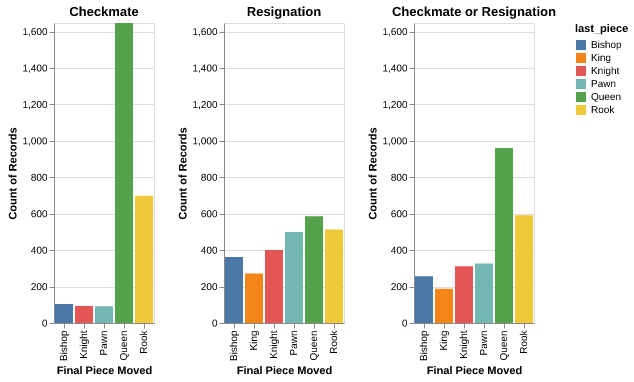

In [29]:
c5 = make_chart(df_mate, "Checkmate", max_count)
c6 = make_chart(df_resign, "Resignation", max_count)
c7 = make_chart(df_filter, "Checkmate or Resignation", max_count)

c5 | c6 | c7

From these charts we can see that the queen is the most common final move in all cases, but happens the most in games that specifically end in checkmates.

One interesting thing to note is that we never actually see a king being a final move to checkmate (which is possible). In resignations, it is the final move over 200 times. 

Seeing as the pawns, knights, and bishops seem to show up a similar amount in each chart, I would like to examine this further by using decision trees and k nearest neighbor classifiers. I will be using "turns", "time_minutes", and "total_captures" as features, so I find it fitting to first make a chart showing how these 3 features relate to one another. 

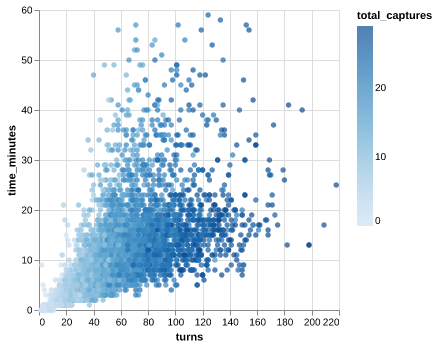

In [30]:
df_short = df[df["time_minutes"] <= 60]

alt.Chart(df_short[:5000]).mark_circle().encode(
    x = "turns",
    y = "time_minutes",
    color = "total_captures"
)

The chart orignially included all times, but it was too zoomed out so I limited it to a max of 60 minutes.

Based on the chart, it seems that as the turns increase, so does the time and total captures in the match which makes logical sense. 

## Predicting Final Piece Moved Using Decision Tree

In this section I will be using a decision tree with the "time_minutes", "total_captures", and "turns" columns as features to predict which piece was moved last.

I will start by making a new dataframe which only contains rows where a pawn, knight, or bishop was the final move.

In [31]:
df_pkb = df[(df["last_piece"] == "Pawn") | (df["last_piece"] == "Knight") | (df["last_piece"] == "Bishop")]

Now creating a train and test set with 50% being used in training. I want to see if we can use the length of the match, total captures, and amount of turns to determine which piece was moved last.

In [32]:
cols = ["time_minutes","total_captures", "turns"]

X = df_pkb[cols]
y = df_pkb["last_piece"]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.5, random_state = 128)

Lets determine the best leaf node. I will be making a chart based on this Twitter post provided by my professor, Hongwei Gao: https://x.com/daniela_witten/status/1292293102103748609?s=20

I will do this by creating a new dataframe containing the columns:
* "leaves" which gives number of leaf nodes
* "error" which is the error in either the train or test set
* "set" which says if it is the train or test set

In [33]:
df_err = pd.DataFrame(columns=["leaves", "error", "set"])

for i in range(2, 21):
    clf = DecisionTreeClassifier(max_leaf_nodes=i)
    clf.fit(X_train, y_train)
    
    train_error = 1 - clf.score(X_train, y_train)
    test_error = 1 - clf.score(X_test, y_test)
    
    df_err.loc[len(df_err)] = {"leaves": i, "error": train_error, "set": "train"}
    df_err.loc[len(df_err)] = {"leaves": i, "error": test_error, "set": "test"}


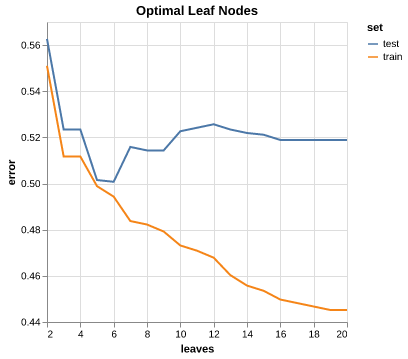

In [34]:
alt.Chart(df_err).mark_line().encode(
    x="leaves:Q",
    y= alt.Y("error:Q", scale = alt.Scale(zero = False)),
    color="set:N"
).properties(title = "Optimal Leaf Nodes")

From the chart we can see that the testing set line hits its low point then begins to go up at 6 leaf nodes, so this is the what will be used for the decision tree.

In [35]:
clf = DecisionTreeClassifier(max_leaf_nodes = 6)

clf.fit(X_train, y_train)

print("Training Score:", clf.score(X_train, y_train))
print("Testing Score:", clf.score(X_test, y_test))
print("Score Difference:", abs(clf.score(X_test, y_test) - clf.score(X_train, y_train)))
print()
print("Importance of time_minutes feature:", clf.feature_importances_[0])
print("Importance of total_captures feature:", clf.feature_importances_[1])
print("Importance of turns feature:", clf.feature_importances_[2])

Training Score: 0.5056689342403629
Testing Score: 0.49924471299093653
Score Difference: 0.006424221249426321

Importance of time_minutes feature: 0.03282081565931197
Importance of total_captures feature: 0.12652163869646119
Importance of turns feature: 0.8406575456442269


Using clf.score, we can see that the training and test score are both around 50% so it suggests that the data is underfit. The scores however, are very close being within around .6% of each other, so the model at least generalizes well between the two sets.

The score we received from the training set indicates that the final piece moved can be predicted about 50% of the time which is at least an increase going up from the roughly 33% random chance that it would take to guess which of the pieces performed the final move.

Using the feature importance score, we see that the turn feature had the most impact in the decision and the total captures had the second most impact. Finally, time in minutes had the least impact.

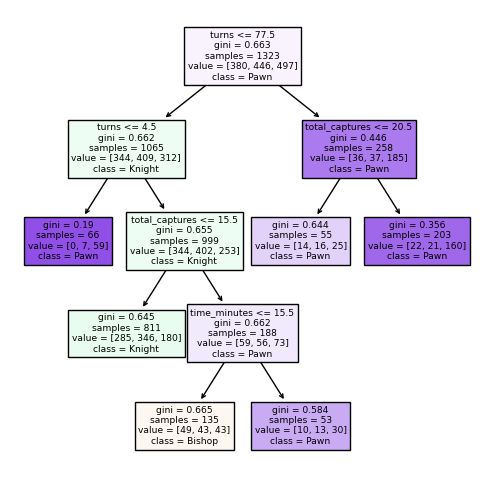

In [36]:
fig = plt.figure(figsize=(6,6))
_ = tree.plot_tree(clf, 
                   feature_names=clf.feature_names_in_,  
                   class_names=clf.classes_,
                   filled=True)

By inspecting the decision tree we can see that the knight and bishop sample counts are often pretty similar to each other while the pawns are a more distinguishing factor. I expect that this has happened since they share the same material value of 3 while a pawn has value 1.

I suspect that the reason we have a 50% accuracy on the test is due to the fact that it does a decent job distinguishing between whether or not the final piece was a pawn, but struggles in distinguishing between the knight and bishop resulting in the 50% accuracy that we see. 

## K Nearest Neighbors Classifier Predictions

In this section I will use K Nearest Neighbors Classifier to try to predict the final piece moved using the same features as in the decision tree. I want to see how the different models compare to one another in regards to their accuracy.

In [37]:
cols = ["time_minutes", "total_captures", "turns"]

X = df_pkb[cols]
y = df_pkb["last_piece"]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.4, random_state = 128)

By adapting code on the elbow method from https://www.geeksforgeeks.org/how-to-find-the-optimal-value-of-k-in-knn/# I will find the optimal number of neighbors to use for the prediction.

To begin, I will make 2 new dataframes, one with the amount of neighbors and their error values, then another with the optimal number of neighbors.

In [38]:
df_err2 = pd.DataFrame(columns=["neighbors", "error"])

for i in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors = i)
    knn.fit(X_train, y_train)
    
    error_rate = 1 - knn.score(X_test, y_test)
    
    df_err2.loc[len(df_err2)] = {"neighbors": i, "error": error_rate}

In [39]:
optimal_k = df_err2.loc[df_err2["error"].idxmin(), "neighbors"]

df_k = pd.DataFrame({"neighbors": [optimal_k]})

Now I will create a line chart which shows the error as a function of the number of neighbors and a line showing the optimal number of neighbors.

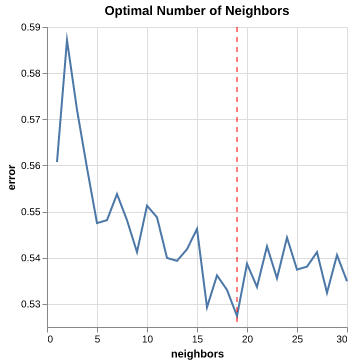

In [40]:
c5 = alt.Chart(df_err2).mark_line().encode(
    x="neighbors:Q",
    y= alt.Y("error:Q", scale = alt.Scale(zero = False))
   
)

c6 = alt.Chart(df_k).mark_rule(strokeDash = [5, 5], color = "red").encode(
    x="neighbors:Q"
)

(c5 + c6).properties(title = "Optimal Number of Neighbors")

Based on the chart, we can see that the optimal number of neighbors is 19, thus that is the amount we will be using. Another thing to note is that this helps to confirm the idea that odd numbers are better choices for neighbors than even numbers as stated in the article I used to help make this chart: https://www.geeksforgeeks.org/how-to-find-the-optimal-value-of-k-in-knn/# 

In [41]:
knn = KNeighborsClassifier(n_neighbors = 19)

knn.fit(X_train, y_train)

print("Training Score:", knn.score(X_train, y_train))
print("Testing Score:", knn.score(X_test, y_test))
print("Score Difference:", abs(knn.score(X_test, y_test) - knn.score(X_train, y_train)))

Training Score: 0.5255198487712666
Testing Score: 0.4726242920075519
Score Difference: 0.05289555676371466


Recalling earlier that with the decision tree we had almost 50% accuracy on the test set, it seems that it performed better than the 47% given by the K Nearest Neighbors. Also, with the decision tree, the difference between the testing and training scores was much smaller than with the K Nearest Neighbors. Because of this, I assume that decision trees do a better job at generalizing.

Note: I experimented with different training sizes and found that with train size of 0.4, it gave the smallest difference between the testing and training scores, so that is what I used.

## Graph of K Nearest Neighbors Predictions

Using the "total_captures" and "turns" columns, I will create a graph to visualize the predictions. To begin I will refit K Nearest Neighbors to use only total_captures and turns to predict last_piece.

In [42]:
cols2 = ["total_captures", "turns"]

X = df_pkb[cols2]
y = df_pkb["last_piece"]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.4, random_state = 128)

knn2 = KNeighborsClassifier(n_neighbors = 27)

knn2.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=27)

 I will make a graph to see how I want to spread out np.linspace

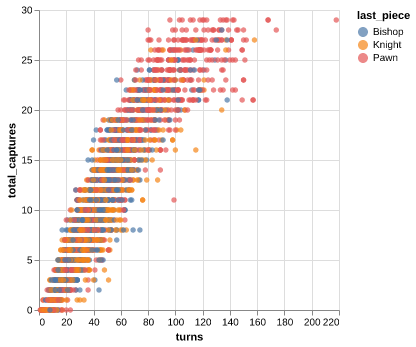

In [43]:
alt.Chart(df_pkb).mark_circle().encode(
    x = alt.X("turns", scale = alt.Scale(zero = False)),
    y = alt.Y("total_captures", scale = alt.Scale(zero = False)),
    color = "last_piece"
)

With turns, there seems to only be a few points falling beyond 150, and most falling before, so I will be setting the range between 0 and 150.

With total captures, the range is between 0 and 30 (which makes sense since the most possible captures in chess is 30).

In [44]:
x = np.linspace(0,150,75)
y = np.linspace(0,30,75)

In [45]:
df_art = pd.DataFrame(list(product(x, y)), columns = ["turns", "total_captures"])

I will now add a column containing the predictions based on turns and total_captures.

In [46]:
df_art["pred"] = knn2.predict(df_art[cols2])
df_art

,turns,total_captures,pred
0,0.0,0.000000,Pawn
1,0.0,0.405405,Pawn
2,0.0,0.810811,Pawn
3,0.0,1.216216,Pawn
4,0.0,1.621622,Pawn
...,...,...,...
5620,150.0,28.378378,Pawn
5621,150.0,28.783784,Pawn
5622,150.0,29.189189,Pawn
5623,150.0,29.594595,Pawn


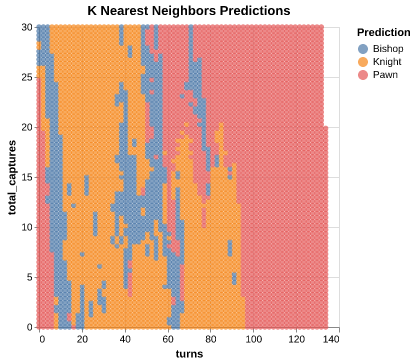

In [47]:
alt.Chart(df_art[:5000]).mark_circle().encode(
    x = alt.X("turns", scale = alt.Scale(zero = False)),
    y = alt.Y("total_captures", scale = alt.Scale(zero = False)),
    color = alt.Color("pred", title = "Prediction")
).properties(title = "K Nearest Neighbors Predictions")

Based on this, it seems pawns are more likely to be predicted when there are either a very small amount of turns or a very large amount of turns while it seems that in the middle it is mostly bishops or knights but with a fairly even split.

## Summary

In this project I looked at wins based on player rating, final piece moves based on game outcome, and analyzed the differences between machine learning algorithms. In looking at how player rating affects the winner I found that the player with the higher rating wins more than 62% of the time in all rating ranges. With game outcomes I found that the most common final piece move is the queen. With machine learning algorithms, I found that the decision tree performed better than the K Nearest Neighbors.

## References

* Source of dataset
https://openml.org/search?type=data&status=active&id=45951&sort=runs

* Other references used
https://x.com/daniela_witten/status/1292293102103748609?s=20
https://www.geeksforgeeks.org/how-to-find-the-optimal-value-of-k-in-knn/



<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=4987f2d1-db11-4d5d-b8fd-7551f1bd7a52' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>